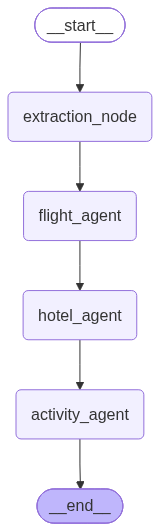

In [1]:
import os
import requests
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import Optional, List, TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END

# Load local environment variables from .env
load_dotenv()

MOCK_API_BASE_URL = os.getenv("MOCK_API_BASE_URL", "http://localhost:3000")

# Pydantic schemas
class HotelState(BaseModel):
    hotelName: str
    city: str
    cityCode: str
    country: str
    pricePerNight: str
    rating: str
    availableRooms: str
    hotelID: str

class FlightState(BaseModel):
    flightName: str
    origin: str
    originCode: str
    destination: str
    destinationCode: str
    departureTime: str
    arrivalTime: str
    duration: str
    price: str
    availableSeats: str
    flightID: str

class ActivityState(BaseModel):
    activityName: str
    city: str
    cityCode: str
    country: str
    description: str
    price: str
    duration: str
    activityID: str

class State(TypedDict):
    message: str
    origin_city: str
    destination_city: str
    travel_date: str
    budget: str
    min_cost: str
    hotel_state: List[HotelState]
    flight_state: List[FlightState]
    activity_state: List[ActivityState]

class TravelDetails(BaseModel):
    origin_city: str = Field(description="The starting city of the travel. Defaults to 'Berlin'.")
    destination_city: str = Field(description="The destination city of the travel. Defaults to 'Frankfurt'.")
    travel_date: Optional[str] = Field(description="The date or season of travel if mentioned, e.g., 'next summer', '2026-08-09'. Defaults to 'Not specified'.")
    budget: Optional[str] = Field(description="The budget of travel if mentioned, e.g., '1000', 'cheap'. Defaults to 'Not specified'.")

# Client request functions
def get_available_flights(origin: str, destination: str) -> list:
    url = f"{MOCK_API_BASE_URL}/flights/available_flights"
    params = {"origin": origin, "destination": destination}
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error fetching flights: {e}")
        return []

def get_available_hotels(city: str, rating: float = None) -> list:
    url = f"{MOCK_API_BASE_URL}/hotels/available_hotels"
    params = {"city": city}
    if rating is not None:
        params["rating"] = rating
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error fetching hotels: {e}")
        return []

def get_available_activities(city: str) -> list:
    url = f"{MOCK_API_BASE_URL}/thingsToDo/available_activities"
    params = {"city": city}
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"Error fetching activities: {e}")
        return []

def extract_travel_details(message: str) -> dict:
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key or api_key == "your-api-key":
        raise ValueError("GROQ_API_KEY is not configured in the environment.")

    llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)
    structured_llm = llm.with_structured_output(TravelDetails)
    
    prompt = f"Extract travel details from this user query: '{message}'"
    result = structured_llm.invoke(prompt)
    
    return {
        "origin_city": result.origin_city or "Berlin",
        "destination_city": result.destination_city or "Frankfurt",
        "travel_date": result.travel_date or "Not specified",
        "budget": result.budget or "Not specified"
    }

def extraction_node(state: State) -> dict:
    details = extract_travel_details(state["message"])
    return {
        "origin_city": details["origin_city"],
        "destination_city": details["destination_city"],
        "travel_date": details["travel_date"],
        "budget": details["budget"]
    }

def flight_agent(state: State) -> dict:
    flights_data = get_available_flights(state["origin_city"], state["destination_city"])
    flights = [FlightState(**f) for f in flights_data]
    return {
        "flight_state": flights,
        "message": state["message"] + f"\n\nFlights found:\n" + \
                   "\n".join([f"- {f.flightName} ({f.flightID}): {f.origin} -> {f.destination}, Price: {f.price}" for f in flights])
    }

def hotel_agent(state: State) -> dict:
    hotels_data = get_available_hotels(state["destination_city"])
    hotels = [HotelState(**h) for h in hotels_data]
    return {
        "hotel_state": hotels,
        "message": state["message"] + f"\n\nHotels found:\n" + \
                   "\n".join([f"- {h.hotelName} ({h.hotelID}) in {h.city}, Price: {h.pricePerNight}" for h in hotels])
    }

def activity_agent(state: State) -> dict:
    activities_data = get_available_activities(state["destination_city"])
    activities = [ActivityState(**a) for a in activities_data]
    
    # Calculate cheapest options
    cheapest_flight = min(state["flight_state"], key=lambda x: int(float(x.price))) if state["flight_state"] else None
    cheapest_hotel = min(state["hotel_state"], key=lambda x: int(float(x.pricePerNight))) if state["hotel_state"] else None
    cheapest_activity = min(activities, key=lambda x: int(float(x.price))) if activities else None
    
    flight_cost = int(float(cheapest_flight.price)) if cheapest_flight else 0
    hotel_cost = int(float(cheapest_hotel.pricePerNight)) if cheapest_hotel else 0
    activity_cost = int(float(cheapest_activity.price)) if cheapest_activity else 0
    total_min = flight_cost + hotel_cost + activity_cost
    
    min_cost_str = str(total_min)
    
    # Prefix the summary recommendation to the message response
    prefix_summary = f"Lowest Cost to Make this Trip Work: €{total_min}\n" \
                     f"- Cheapest Flight: {cheapest_flight.flightName if cheapest_flight else 'N/A'} (€{flight_cost})\n" \
                     f"- Cheapest Accommodation: {cheapest_hotel.hotelName if cheapest_hotel else 'N/A'} (€{hotel_cost})\n" \
                     f"- Cheapest Activity: {cheapest_activity.activityName if cheapest_activity else 'N/A'} (€{activity_cost})\n\n" \
                     f"Parsed Travel Plan Parameters:\n" \
                     f"- Origin: {state.get('origin_city')}\n" \
                     f"- Destination: {state.get('destination_city')}\n" \
                     f"- Travel Date: {state.get('travel_date')}\n" \
                     f"- Target Budget: {state.get('budget')}\n\n"
    
    return {
        "activity_state": activities,
        "min_cost": min_cost_str,
        "message": prefix_summary + state["message"] + f"\n\nActivities found:\n" + \
                   "\n".join([f"- {a.activityName} ({a.activityID}): {a.description}, Price: {a.price}" for a in activities])
    }

# Build LangGraph workflow
builder = StateGraph(State)

builder.add_node("extraction_node", extraction_node)
builder.add_node("flight_agent", flight_agent)
builder.add_node("hotel_agent", hotel_agent)
builder.add_node("activity_agent", activity_agent)

builder.add_edge(START, "extraction_node")
builder.add_edge("extraction_node", "flight_agent")
builder.add_edge("flight_agent", "hotel_agent")
builder.add_edge("hotel_agent", "activity_agent")
builder.add_edge("activity_agent", END)

# Compiled graph ready to be invoked
graph = builder.compile()
graph


In [2]:
result = graph.invoke({
    "message": "Planning a trip from Berlin to Paris for next summer",
    "origin_city": "",
    "destination_city": "",
    "travel_date": "",
    "budget": "",
    "min_cost": "",
    "flight_state": [],
    "hotel_state": [],
    "activity_state": []
})

print("Message:", result["message"])
print("\nCheapest cost calculated:", result["min_cost"])


Message: Lowest Cost to Make this Trip Work: €10000
- Cheapest Flight: N/A (€0)
- Cheapest Accommodation: Novotel Paris Les Halles (€8000)
- Cheapest Activity: Louvre Museum Guided Tour (€2000)

Parsed Travel Plan Parameters:
- Origin: Berlin
- Destination: Paris
- Travel Date: next summer
- Target Budget: Not specified

Planning a trip from Berlin to Paris for next summer

Flights found:


Hotels found:
- Hôtel Ritz Paris (HTL-PAR-031) in Paris, Price: 15300
- Le Bristol Paris (HTL-PAR-035) in Paris, Price: 19300
- Four Seasons Hotel George V (HTL-PAR-044) in Paris, Price: 8200
- Hôtel Plaza Athénée (HTL-PAR-046) in Paris, Price: 13400
- Shangri-La Paris (HTL-PAR-071) in Paris, Price: 10200
- The Peninsula Paris (HTL-PAR-119) in Paris, Price: 28600
- Mandarin Oriental Paris (HTL-PAR-128) in Paris, Price: 24500
- Pullman Paris Tour Eiffel (HTL-PAR-135) in Paris, Price: 25900
- L'Hôtel Paris (HTL-PAR-183) in Paris, Price: 25300
- Hôtel Regina Louvre (HTL-PAR-204) in Paris, Price: 20200
